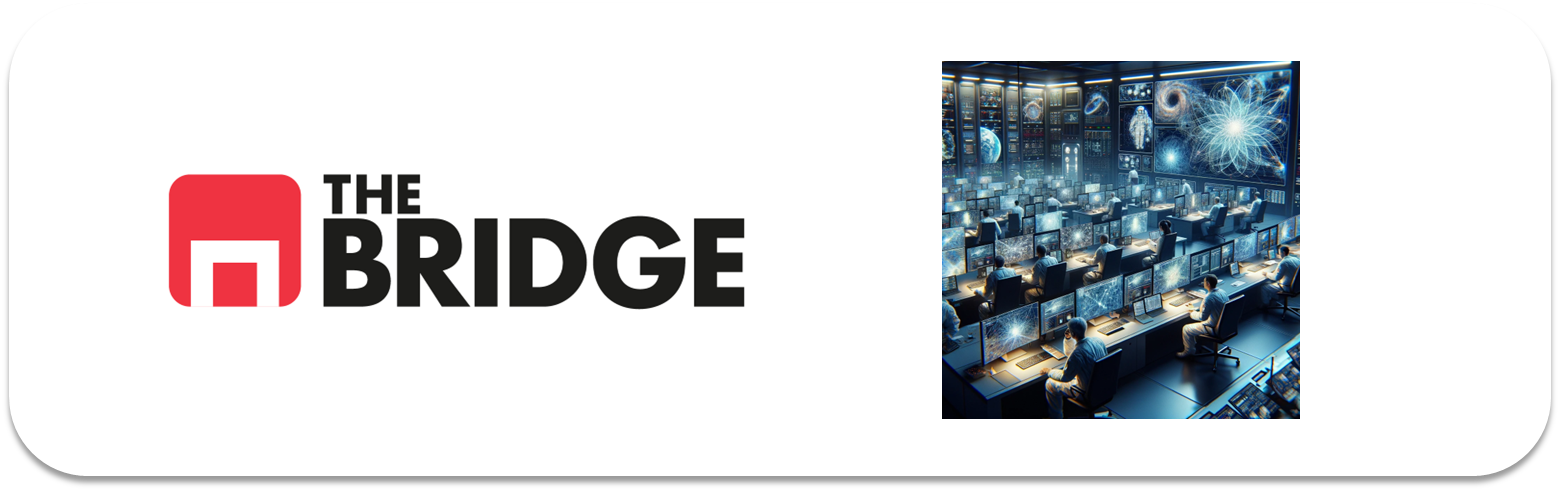

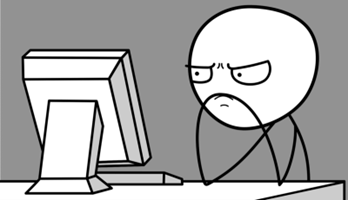

Para ejercitarte y afianzar lo aprendido sobre **Redes Convolucionales**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
# --- Manejo de datos y ficheros ---
import os
import gc
import numpy as np
import pandas as pd

# --- Lectura y redimensionado de imagenes ---
from skimage.io import imread
import cv2

# --- Visualizacion ---
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bt          # utilidades de visualizacion del bootcamp

# --- Utilidades de sklearn ---
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# --- Keras / Deep Learning ---
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

# Semillas para que el notebook sea reproducible
SEMILLA = 42
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## El problema de "Negocio"
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en https://www.kaggle.com/datasets/puneet6060/intel-image-classification?select=seg_test como `seg_train.zip` y `seg_test.zip` (o bien en el botón de download).  

NOTA: Son archivos bastante grandes (386MB en total). Por supuesto, no es necesario que tengas que mantenerlos en tu ordenador una vez realizado el ejercicio, bórralos si es el caso.




### Ejercicio 1

Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones). Para ello:

1. Descarga las imagenes del repositorio de Kaggle en el directorio que vayas a emplear para el ejercicio.
2. Descomprime los datos (son ficheros de imágenes) de forma que tengas dos subdirectorios seg_train y seg_test en el que estén ya colgando directamente los directorios de cada clase de paisajes. Si descargaste seg_pred, puedes eliminarlo.
3. Crea unas variables como las siguientes (ajustándolas a tu caso/rutas particulares):

```python
ROOT_PATH = './data/'
TRAIN_PATH = ROOT_PATH + "seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/"
```
4. Utiliza la siguiente función para crear los X_train, y_train y X_test e y_test:

```python
def read_data(directorio, reshape_dim = (32,32)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):

                image = imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim) # Redimensionamos las imágenes a 32x32

                X.append(image)
                y.append(folder)

    return np.array(X),np.array(y)
```


*Pues copiamos lo que nos dicen y lo aplicamos a los dos directorios para tener las X y las y*

Antes de copiar la función, hacemos lo que pide el enunciado: **mirar cómo están
almacenados los datos**. Definimos las rutas y recorremos la estructura de
directorios.

In [2]:
ROOT_PATH = './data/'
TRAIN_PATH = ROOT_PATH + "seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/"

# Vemos la estructura: cada clase es un subdirectorio
for ruta, nombre in [(TRAIN_PATH, "TRAIN"), (TEST_PATH, "TEST")]:
    print(f"--- {nombre} ({ruta}) ---")
    total = 0
    for carpeta in sorted(os.listdir(ruta)):
        if os.path.isdir(os.path.join(ruta, carpeta)):
            n = len(os.listdir(os.path.join(ruta, carpeta)))
            total += n
            print(f"   {carpeta:12} {n:5} imagenes")
    print(f"   {'TOTAL':12} {total:5} imagenes\n")

--- TRAIN (./data/seg_train/) ---
   buildings     2191 imagenes
   forest        2271 imagenes
   glacier       2404 imagenes
   mountain      2512 imagenes
   sea           2274 imagenes
   street        2382 imagenes
   TOTAL        14034 imagenes

--- TEST (./data/seg_test/) ---
   buildings      437 imagenes
   forest         474 imagenes
   glacier        553 imagenes
   mountain       525 imagenes
   sea            510 imagenes
   street         501 imagenes
   TOTAL         3000 imagenes



Tenemos **6 clases** de paisajes (`buildings`, `forest`, `glacier`, `mountain`,
`sea`, `street`), con unas 14.000 imágenes de train y 3.000 de test. Es un problema
de **clasificación multiclase**, a diferencia del MNIST del workout que tenía 10
clases pero en escala de grises.

Miramos también el tamaño original de alguna imagen, para saber de dónde partimos
antes de redimensionar:

In [3]:
# Tamano original de unas cuantas imagenes de ejemplo
carpeta_ejemplo = TRAIN_PATH + "forest/"
for fichero in sorted(os.listdir(carpeta_ejemplo))[:5]:
    imagen = imread(carpeta_ejemplo + fichero)
    print(f"{fichero}: {imagen.shape}")

10007.jpg: (150, 150, 3)
10010.jpg: (150, 150, 3)
10020.jpg: (150, 150, 3)
10030.jpg: (150, 150, 3)
10037.jpg: (150, 150, 3)


Las originales son de 150x150 píxeles y 3 canales (RGB). Al redimensionar a 32x32
vamos a perder mucho detalle, pero el enunciado lo recomienda para que las
ejecuciones sean rápidas. En el ejercicio EXTRA subiremos la resolución para ver
cuánto influye.

Y ahora sí, copiamos la función que nos dan en el enunciado:

In [4]:
def read_data(directorio, reshape_dim = (32,32)):
    """Lee todas las imagenes de un directorio, etiquetandolas con el nombre
    de la carpeta en la que estan, y las redimensiona a reshape_dim.
    """
    X = []
    y = []
    for folder in os.listdir(directorio):
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):

                image = imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim) # Redimensionamos las imágenes a 32x32

                X.append(image)
                y.append(folder)

    return np.array(X),np.array(y)

La aplicamos a los dos directorios. Tarda unos 50 segundos, porque son 17.000
imágenes que hay que abrir y redimensionar una a una.

In [5]:
RESHAPE_DIM = (32, 32)

X_train, y_train = read_data(TRAIN_PATH, RESHAPE_DIM)
X_test, y_test = read_data(TEST_PATH, RESHAPE_DIM)

print("TRAIN -> X:", X_train.shape, "| y:", y_train.shape)
print("TEST  -> X:", X_test.shape, "| y:", y_test.shape)

TRAIN -> X: (14034, 32, 32, 3) | y: (14034,)
TEST  -> X: (3000, 32, 32, 3) | y: (3000,)


**Un detalle importante que conviene mirar ya**: la función recorre las carpetas
una a una, así que los datos salen **agrupados por clase**, no mezclados.

In [6]:
# Comprobamos el orden en el que han quedado las etiquetas
print("Primeras 5 etiquetas:", y_train[:5])
print("Ultimas 5 etiquetas :", y_train[-5:])
print()
print("Asi es como aparecen las clases al recorrer y_train:")
# np.unique con return_index nos dice donde aparece por primera vez cada clase
clases_vistas, primera_aparicion = np.unique(y_train, return_index=True)
for clase, posicion in sorted(zip(clases_vistas, primera_aparicion), key=lambda x: x[1]):
    print(f"   {clase:12} aparece por primera vez en la posicion {posicion}")

Primeras 5 etiquetas: ['buildings' 'buildings' 'buildings' 'buildings' 'buildings']
Ultimas 5 etiquetas : ['street' 'street' 'street' 'street' 'street']

Asi es como aparecen las clases al recorrer y_train:
   buildings    aparece por primera vez en la posicion 0
   forest       aparece por primera vez en la posicion 2191
   glacier      aparece por primera vez en la posicion 4462
   mountain     aparece por primera vez en la posicion 6866
   sea          aparece por primera vez en la posicion 9378
   street       aparece por primera vez en la posicion 11652


Confirmado: primero todas las de `buildings`, luego todas las de `forest`, etc.
Esto nos va a obligar a **barajar los datos** antes de entrenar, y es justo a lo
que se refiere la nota del Ejercicio 6 ("tendrás que preparar un poco los X,y
antes"). Lo dejamos apuntado y lo resolvemos ahí.

### Ejercicio 2

Haz la visualización del dataset: comprueba cuantos datos tienes, que forma, investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.


Empezamos con lo que pide el enunciado: cuántos datos, qué forma y una inspección
de las imágenes.

In [7]:
print("=== Cuantos datos y que forma ===")
print(f"X_train: {X_train.shape}  ->  {X_train.shape[0]} imagenes de "
      f"{X_train.shape[1]}x{X_train.shape[2]} pixeles y {X_train.shape[3]} canales")
print(f"X_test : {X_test.shape}")
print()
print("=== Como son los datos ===")
print("Tipo de dato :", X_train.dtype)
print("Valor minimo :", X_train.min())
print("Valor maximo :", X_train.max())
print("Hay NaN?     :", np.isnan(X_train).any())
print()
print("=== Memoria que ocupan ===")
print(f"X_train: {X_train.nbytes / 1e6:.1f} MB")
print(f"X_test : {X_test.nbytes / 1e6:.1f} MB")

=== Cuantos datos y que forma ===
X_train: (14034, 32, 32, 3)  ->  14034 imagenes de 32x32 pixeles y 3 canales
X_test : (3000, 32, 32, 3)

=== Como son los datos ===
Tipo de dato : uint8
Valor minimo : 0
Valor maximo : 255
Hay NaN?     : False

=== Memoria que ocupan ===
X_train: 43.1 MB
X_test : 9.2 MB


Valores enteros de 0 a 255 en tres canales, sin datos ausentes.

Para comprobar que hemos cargado bien los datos necesitamos **verlos**. Adaptamos
la función `plot_digits` del workout: como ahora las imágenes son en color,
quitamos el `cmap="Greys"` y dejamos que matplotlib pinte el RGB directamente.

In [8]:
def plot_imagenes(imagenes, etiquetas=None, n_cols=5, titulo=None):
    """Pinta un conjunto de imagenes en una rejilla, con su etiqueta encima.

    Args:
        imagenes: array de imagenes (n, alto, ancho, 3).
        etiquetas: lista/array de textos a poner como titulo de cada imagen.
        n_cols: numero de columnas de la rejilla.
        titulo: titulo general de la figura.
    """
    n_filas = (len(imagenes) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 2, n_filas * 2.3))

    for indice, imagen in enumerate(imagenes):
        plt.subplot(n_filas, n_cols, indice + 1)
        plt.imshow(imagen)
        plt.axis("off")
        if etiquetas is not None:
            plt.title(etiquetas[indice], fontsize=9)

    if titulo:
        plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()

Miramos una muestra **aleatoria** (no las primeras, que serían todas `buildings`):

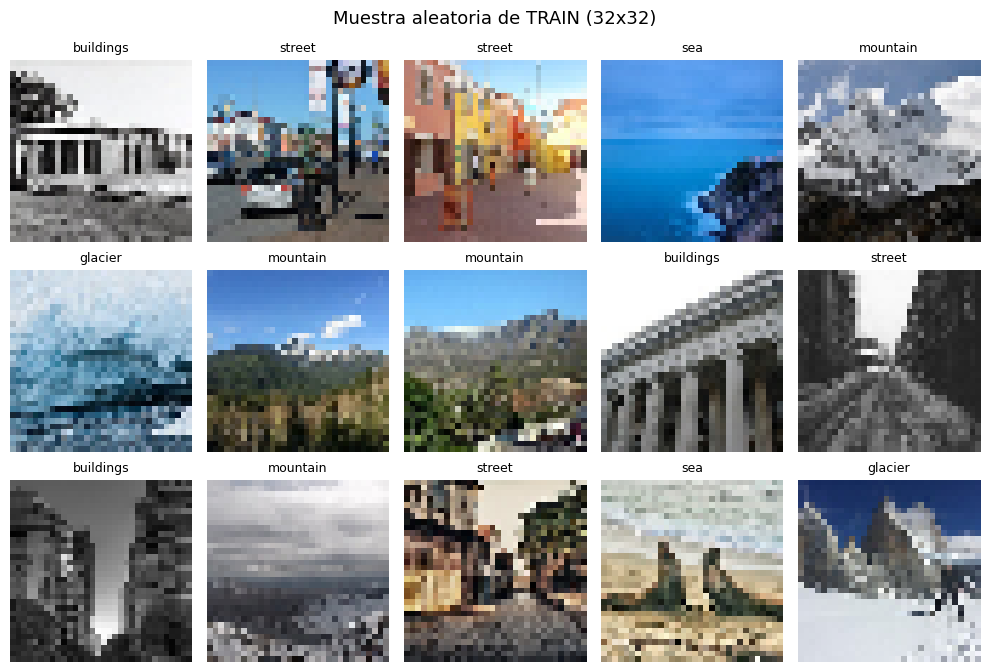

In [9]:
indices = np.random.choice(len(X_train), 15, replace=False)
plot_imagenes(X_train[indices], y_train[indices], n_cols=5,
              titulo="Muestra aleatoria de TRAIN (32x32)")

Y ahora unas cuantas **de cada clase**, que es la mejor forma de comprobar que las
etiquetas se han asignado bien (cada fila debería ser coherente con su nombre):

Clases: [np.str_('buildings'), np.str_('forest'), np.str_('glacier'), np.str_('mountain'), np.str_('sea'), np.str_('street')]


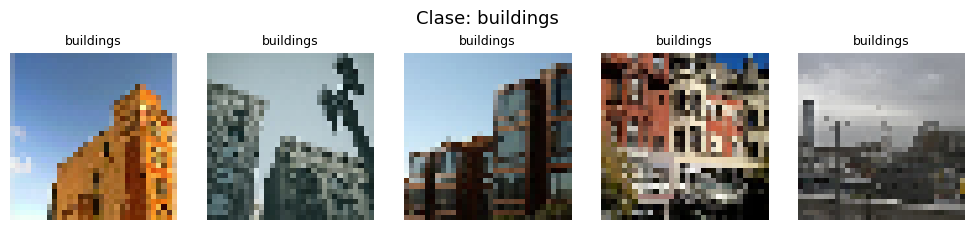

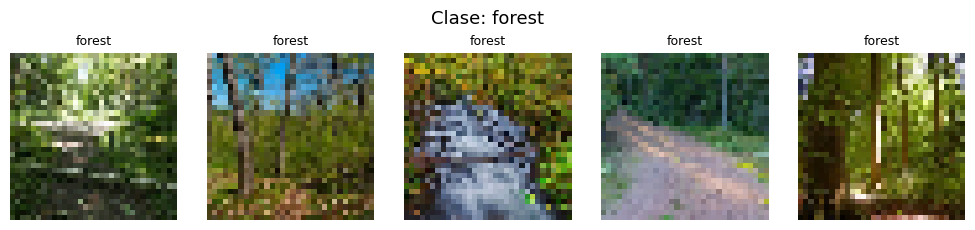

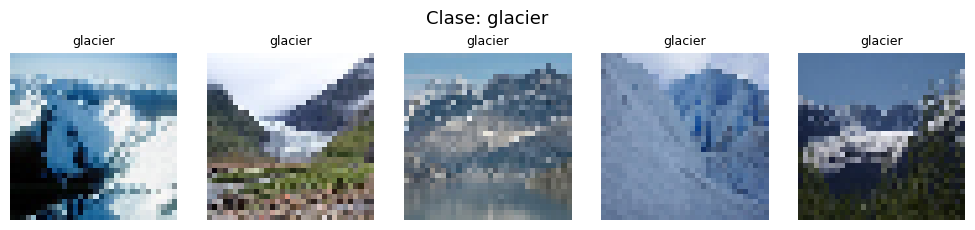

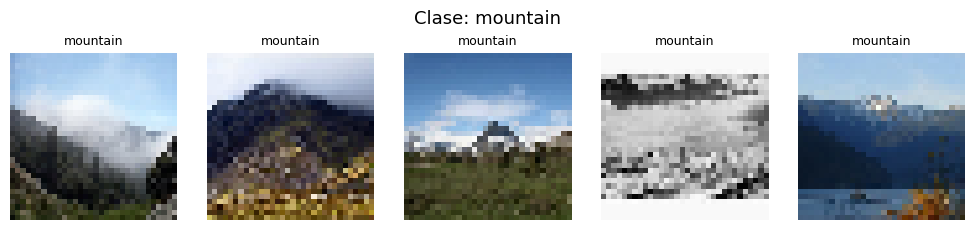

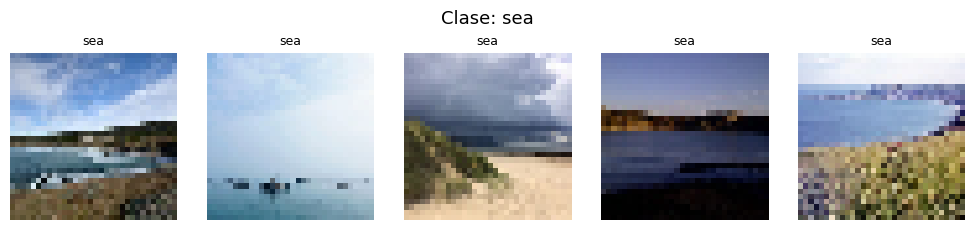

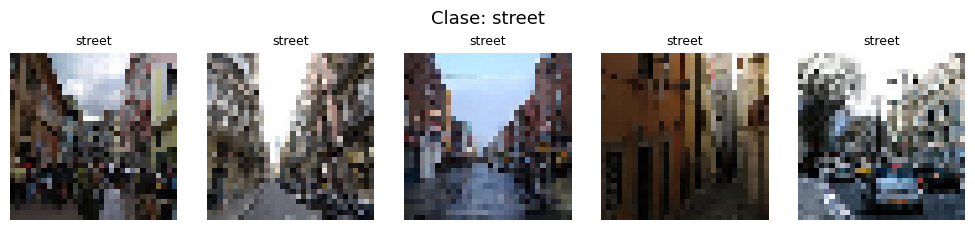

In [10]:
CLASES = sorted(np.unique(y_train))
print("Clases:", CLASES)

# 5 imagenes de cada clase para verificar que las etiquetas son correctas
for clase in CLASES:
    indices_clase = np.where(y_train == clase)[0]
    muestra = np.random.choice(indices_clase, 5, replace=False)
    plot_imagenes(X_train[muestra], [clase] * 5, n_cols=5,
                  titulo=f"Clase: {clase}")

**Conclusiones de la visualización**

Las etiquetas están bien puestas: cada fila se corresponde con su clase. Pero
mirando las imágenes ya se intuye dónde va a sufrir el modelo:

* `glacier` y `mountain` se parecen muchísimo: las dos son montañas, y muchas de
  las de glaciar tienen montañas de fondo. A 32x32 la diferencia (hielo vs roca)
  casi desaparece.
* `buildings` y `street` comparten prácticamente el mismo contenido: las fotos de
  calle tienen edificios y las de edificios tienen calle. Lo que las distingue es
  cuál es el protagonista, que es un matiz difícil.
* `forest` y `sea` son las más distintas del resto (verde con textura densa, y
  azul con mucha zona plana), así que deberían ser las más fáciles.

Apostamos a que la matriz de confusión va a mostrar justo estos dos pares
confundidos. Lo comprobaremos en el Ejercicio 8.

### Ejercicio 3

Ahora haz un pequeño miniEda y normaliza las features



### MiniEDA

Con imágenes el EDA se centra en **la distribución del target**, porque de ella
depende la métrica que podemos usar. Lo pintamos con `pinta_distribucion_categoricas`
de `bootcampviztools`, que espera un DataFrame, así que montamos uno con las
etiquetas.

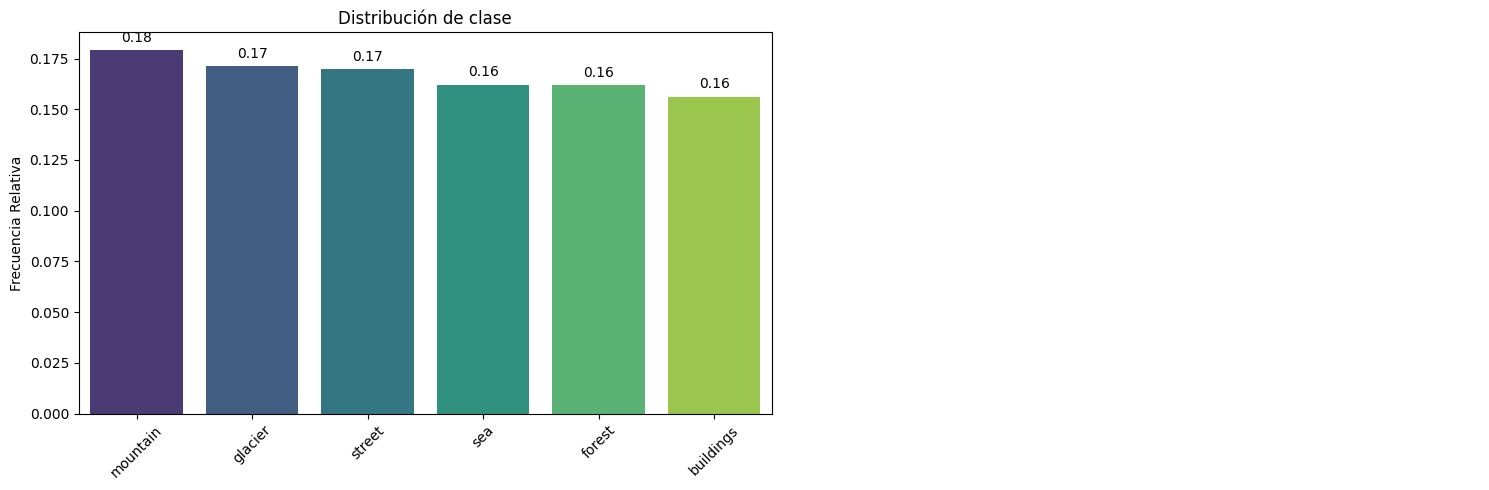

In [11]:
df_train = pd.DataFrame({"clase": y_train})
df_test = pd.DataFrame({"clase": y_test})

bt.pinta_distribucion_categoricas(df_train, ["clase"], relativa=True, mostrar_valores=True)

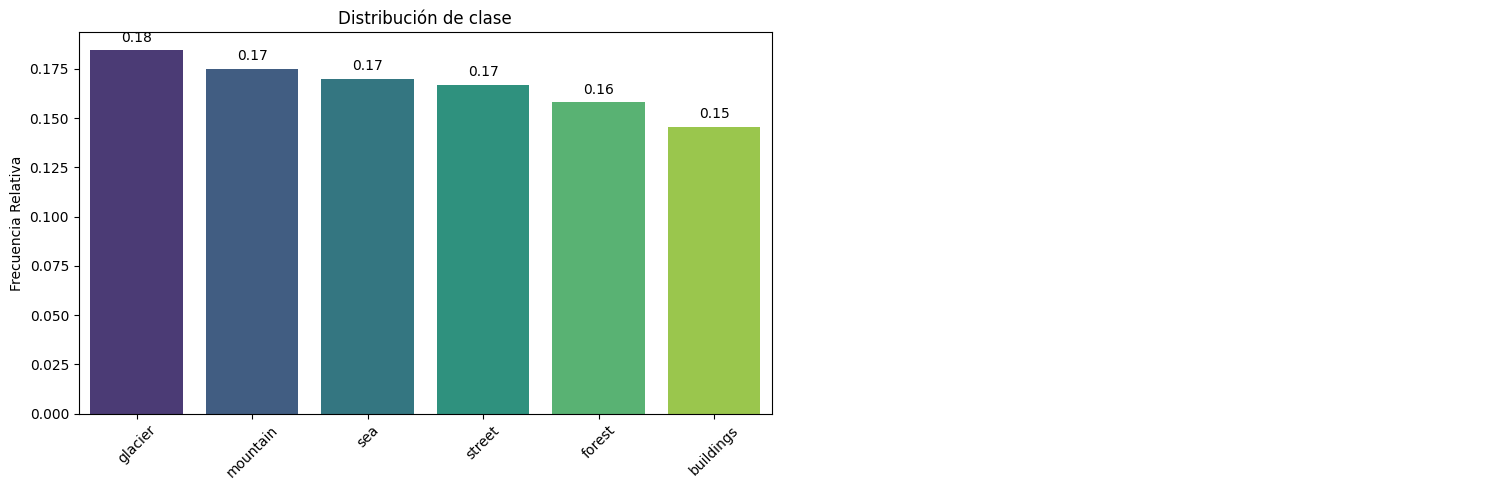

In [12]:
bt.pinta_distribucion_categoricas(df_test, ["clase"], relativa=True, mostrar_valores=True)

In [13]:
# El conteo exacto, para verlo en numeros
print("=== TRAIN ===")
print(df_train["clase"].value_counts().to_string())
print(f"\nProporcion minima: {df_train['clase'].value_counts(normalize=True).min():.3f}")
print(f"Proporcion maxima: {df_train['clase'].value_counts(normalize=True).max():.3f}")
print("\n=== TEST ===")
print(df_test["clase"].value_counts().to_string())

=== TRAIN ===
clase
mountain     2512
glacier      2404
street       2382
sea          2274
forest       2271
buildings    2191

Proporcion minima: 0.156
Proporcion maxima: 0.179

=== TEST ===
clase
glacier      553
mountain     525
sea          510
street       501
forest       474
buildings    437


**Conclusión del miniEDA**: las 6 clases están bastante equilibradas. En train van
del 15,6% (`buildings`) al 17,9% (`mountain`), cuando el reparto perfecto sería
16,7% para cada una. No hay ninguna clase minoritaria.

Por tanto podemos usar **`accuracy`** como métrica, igual que en el workout. El azar
está en **1/6 = 16,7%**, aunque ese suelo es tan bajo que no sirve para juzgar el
modelo: montaremos un baseline mejor justo después de normalizar.

Como métrica de apoyo miraremos el `f1-score` por clase en el informe de
clasificación, porque nos interesa saber si el modelo falla más en unas clases que
en otras (y sospechamos que sí, por lo que hemos visto en el Ejercicio 2).

### Normalización de las features

Dos transformaciones:

1. **Escalar** dividiendo por 255, el truco del workout. Lo hacemos en `float32` y
   no en `float64`: Keras trabaja internamente en `float32`, así que usar el doble
   de precisión solo gastaría el doble de memoria sin ganar nada (y con 14.000
   imágenes eso son cientos de MB).
2. **Pasar las etiquetas a número**, porque Keras no acepta etiquetas de texto.
   Creamos los dos diccionarios de traducción para poder volver a los nombres
   cuando toque interpretar los resultados.

In [14]:
# 1. Escalado a [0, 1] en float32
X_train_esc = (X_train / 255.0).astype("float32")
X_test_esc = (X_test / 255.0).astype("float32")

print("Nuevo minimo:", X_train_esc.min(), "| Nuevo maximo:", X_train_esc.max())
print("Tipo:", X_train_esc.dtype, "| Memoria:", f"{X_train_esc.nbytes / 1e6:.1f} MB")

Nuevo minimo: 0.0 | Nuevo maximo: 1.0
Tipo: float32 | Memoria: 172.4 MB


In [15]:
# 2. Etiquetas de texto a numero. Guardamos los dos diccionarios de traduccion.
clase_a_numero = {clase: i for i, clase in enumerate(CLASES)}
numero_a_clase = {i: clase for clase, i in clase_a_numero.items()}

y_train_num = np.array([clase_a_numero[c] for c in y_train])
y_test_num = np.array([clase_a_numero[c] for c in y_test])

print("clase_a_numero:", clase_a_numero)
print("numero_a_clase:", numero_a_clase)
print()
print("Ejemplo -> etiqueta:", y_train[0], "| numero:", y_train_num[0])

clase_a_numero: {np.str_('buildings'): 0, np.str_('forest'): 1, np.str_('glacier'): 2, np.str_('mountain'): 3, np.str_('sea'): 4, np.str_('street'): 5}
numero_a_clase: {0: np.str_('buildings'), 1: np.str_('forest'), 2: np.str_('glacier'), 3: np.str_('mountain'), 4: np.str_('sea'), 5: np.str_('street')}

Ejemplo -> etiqueta: buildings | numero: 0


### Un baseline antes de la red

Todavía dentro de la preparación, merece la pena establecer **contra qué vamos a
comparar la CNN**. El azar con 6 clases es el 16,7%, pero es un suelo tan bajo que
no informa de nada.

El baseline honesto es un **modelo clásico sobre las imágenes aplanadas**: un
RandomForest al que le damos los píxeles como vector plano, perdiendo toda la
estructura espacial que la convolución sí explota. Si la CNN no bate ese número, no
está aportando nada por el hecho de ser convolucional.

Medimos también **cuánto aporta el color** (RGB frente a escala de grises), que en un
problema de paisajes es una pregunta con sentido.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score


def aplana(imagenes, a_grises=False):
    """Convierte un array de imagenes en la matriz 2D que espera sklearn.

    Los modelos clasicos no entienden de estructura espacial: hay que darles cada
    imagen como un vector plano de pixeles. Opcionalmente pasamos primero a escala
    de grises, para poder medir cuanto aporta el color.

    Args:
        imagenes: array (n, alto, ancho, 3).
        a_grises: si True, colapsa los 3 canales en 1 con los coeficientes de
                  luminancia estandar.

    Returns:
        Matriz (n, n_features).
    """
    if a_grises:
        coeficientes = np.array([0.2989, 0.5870, 0.1140])
        imagenes = np.dot(imagenes[..., :3], coeficientes)

    return imagenes.reshape(len(imagenes), -1)

In [17]:
# Barajamos solo para el baseline, en variables locales, para no tocar los arrays
# principales (el barajado "oficial" se hace en el Ejercicio 6)
X_base, y_base = shuffle(X_train_esc, y_train_num, random_state=SEMILLA)

resultados_baseline = {}

for etiqueta, datos in [("RGB", aplana(X_base)), ("Grises", aplana(X_base, a_grises=True))]:
    # random_state fijo para que el baseline sea reproducible
    rf = RandomForestClassifier(n_estimators=100, random_state=SEMILLA, n_jobs=-1)
    scores = cross_val_score(rf, datos, y_base, cv=5, scoring="accuracy")

    resultados_baseline[etiqueta] = scores.mean()
    print(f"{etiqueta:8} ({datos.shape[1]:5} features)  "
          f"accuracy = {scores.mean():.4f}  (+/- {scores.std():.4f})")

BASELINE_RF = max(resultados_baseline.values())
print()
print(f"Baseline a batir (el mejor de los dos): {BASELINE_RF:.4f}")
print(f"Azar con 6 clases equilibradas       : {1/6:.4f}")

RGB      ( 3072 features)  accuracy = 0.6037  (+/- 0.0054)


Grises   ( 1024 features)  accuracy = 0.5251  (+/- 0.0068)

Baseline a batir (el mejor de los dos): 0.6037
Azar con 6 clases equilibradas       : 0.1667


**Lectura del baseline**

Dos cosas que sacamos de aquí:

1. **El número a batir está en el 60%**, no en el 16,7% del azar. Un RandomForest
   sobre píxeles planos ya clasifica bien 6 de cada 10 paisajes.
2. **El color sí aporta, y mucho**: en RGB el baseline sube unos 8 puntos respecto a
   la escala de grises. Al contrario de lo que pasaría con perros y gatos, aquí el
   color *es* información: el verde saturado de `forest`, el azul de `sea`, los
   grises de `street`. Confirma que hacemos bien en alimentar la red con los 3
   canales en lugar de convertir a grises para ahorrar cómputo.

### Ejercicio 4

Diseña la arquitectura de la red. Recuerda que es un algiritmo de clasificación. Ojo con las dimensiones de la entrada. Como guía, copia o parte de la arquitectura del workout (un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer)


El enunciado nos dice que partamos de la arquitectura del workout (un par de
Conv2D + MaxPooling2D con ReLU, y después la fully connected). Ponemos **tres**
bloques en lugar de dos, porque tenemos 6 clases y fotos de paisajes bastante más
variadas que los dígitos del MNIST.

Dos avisos que menciona el enunciado y que hay que respetar:

* **"Ojo con las dimensiones de la entrada"**: el `input_shape` es `(32, 32, 3)`.
  El 3 son los canales RGB. En el workout era `(28, 28, 1)` porque el MNIST es en
  escala de grises: si copiamos sin pensar, falla.
* **"Recuerda que es un algoritmo de clasificación"**: y multiclase, así que la
  capa de salida lleva **6 unidades** (una por clase) con activación **`softmax`**.

La arquitectura:

| Bloque | Capas | Resolución de salida |
|---|---|---|
| 1 | Conv2D(32, 3x3, same, relu) + MaxPooling2D(2x2) | 16x16x32 |
| 2 | Conv2D(64, 3x3, same, relu) + MaxPooling2D(2x2) + Dropout(0.25) | 8x8x64 |
| 3 | Conv2D(128, 3x3, same, relu) + MaxPooling2D(2x2) + Dropout(0.25) | 4x4x128 |
| cabeza | Flatten + Dense(256, relu) + Dropout(0.5) + Dense(6, softmax) | 6 |

Decisiones:

* **Kernel 3x3**: con imágenes de 32x32, un 5x5 abarcaría una porción demasiado
  grande de la imagen.
* **Padding `same`**: para no ir perdiendo resolución en los bordes en cada
  convolución.
* **Filtros crecientes (32 → 64 → 128)**: el patrón habitual. Cada vez que el
  pooling reduce la resolución a la mitad, duplicamos el número de filtros.
* **Dropout creciente (0.25, 0.25, 0.5)**: más fuerte en la capa densa, que es
  donde se concentran los parámetros y el riesgo de overfitting.

In [18]:
model = Sequential([
    # Ojo con las dimensiones de entrada: 32x32 pixeles y 3 canales (RGB)
    Input(shape=(32, 32, 3)),

    # --- Bloque convolucional 1 ---
    Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),          # 32x32 -> 16x16

    # --- Bloque convolucional 2 ---
    Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),          # 16x16 -> 8x8
    Dropout(0.25),

    # --- Bloque convolucional 3 ---
    Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),          # 8x8 -> 4x4
    Dropout(0.25),

    # --- Cabeza densa: la que clasifica ---
    Flatten(),                               # 4x4x128 -> 2048 features
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(len(CLASES), activation="softmax"),  # 6 clases -> softmax
])

print("Modelo construido. Capas:", len(model.layers))

Modelo construido. Capas: 12


### Ejercicio 5

Escoge el resto de hiperparámetros (optimizador, learning_rate, función de pérdida, métrica,...) y compila el modelo. Muestra un resumen del mismo

Los hiperparámetros que quedan:

* **Optimizador**: `Adam`, que es lo que recomienda el workout cuando el dataset
  de entrenamiento es grande (aquí son 14.034 imágenes x 3072 valores cada una,
  de sobra).
* **Learning rate**: 0.001, el valor por defecto de Adam y el que usa el workout.
  Dejamos `beta_1` y `beta_2` en sus valores por defecto.
* **Función de pérdida**: `sparse_categorical_crossentropy`. Es la que toca porque
  es clasificación multiclase **y** nuestro target es un escalar (0..5). Si
  hubiéramos hecho one-hot encoding de las etiquetas tendríamos que usar
  `categorical_crossentropy`.
* **Métrica**: `accuracy`, que podemos usar porque las clases están equilibradas.

In [19]:
model.compile(
    optimizer=Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999),
    loss="sparse_categorical_crossentropy",   # multiclase con target escalar
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,334 (2.36 MB)

 Trainable params: 619,334 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

**Lectura del `summary`**: unos 619.000 parámetros en total, y de ellos **524.544
están en la `Dense(256)`**, es decir el 85%. Los tres bloques convolucionales
juntos suman apenas 93.000.

Es la idea central de la teoría de esta unidad: la convolución es baratísima en
parámetros porque **comparte pesos** (el mismo filtro se aplica a toda la imagen),
mientras que una capa densa necesita un peso por cada conexión.

### Ejercicio 6

Entrena el modelo reservando un 20% de los datos del entrenamiento para validar y con los callbacks que creas necesarios. NOTA: Ojo, tendrás que preparar un poco los X,y antes.



Aquí está la nota del enunciado: **"Ojo, tendrás que preparar un poco los X,y
antes"**. Se refiere a dos cosas, y la segunda es la importante:

1. Las etiquetas tienen que ser numéricas. Ya lo hicimos en el Ejercicio 3.
2. Hay que **barajar los datos**, y esto no es opcional.

**Por qué el barajado es obligatorio aquí**: vamos a entrenar con
`validation_split=0.2`, y Keras construye ese conjunto de validación cogiendo
**el último 20% de los datos tal y como se los pasamos, sin barajar**. Como
nuestros datos vienen agrupados por clase (lo vimos en el Ejercicio 1), ese último
20% serían unas 2.800 imágenes... **casi todas de `street` y `sea`**.

Es decir: validaríamos contra 2 clases de las 6, y entrenaríamos sin ver
prácticamente ninguna imagen de esas dos. Las métricas de validación no valdrían
absolutamente nada.

Lo comprobamos antes y después de barajar, para verlo con números:

In [20]:
corte = int(len(y_train_num) * 0.8)   # donde Keras cortaria para validar

print("=== SIN barajar: que clases habria en el 20% de validacion ===")
clases_val, cuentas_val = np.unique(y_train_num[corte:], return_counts=True)
for c, n in zip(clases_val, cuentas_val):
    print(f"   {numero_a_clase[c]:12} {n:5}")
print(f"   -> solo {len(clases_val)} clases de {len(CLASES)}. Inservible.")

=== SIN barajar: que clases habria en el 20% de validacion ===
   sea            425
   street        2382
   -> solo 2 clases de 6. Inservible.


In [21]:
# Barajamos. shuffle mantiene la correspondencia entre X e y.
X_train_esc, y_train_num = shuffle(X_train_esc, y_train_num, random_state=SEMILLA)

print("=== DESPUES de barajar: que clases hay en el 20% de validacion ===")
clases_val, cuentas_val = np.unique(y_train_num[corte:], return_counts=True)
for c, n in zip(clases_val, cuentas_val):
    print(f"   {numero_a_clase[c]:12} {n:5}")
print(f"   -> las {len(clases_val)} clases, y bien repartidas.")

=== DESPUES de barajar: que clases hay en el 20% de validacion ===
   buildings      430
   forest         436
   glacier        474
   mountain       514
   sea            477
   street         476
   -> las 6 clases, y bien repartidas.


Ahora sí podemos entrenar. Como callbacks usamos un `EarlyStopping`:

* `monitor="val_loss"`: vigilamos la pérdida en validación, no la de train.
* `patience=8`: le damos 8 épocas de margen antes de cortar.
* `restore_best_weights=True`: **imprescindible**. Sin esto nos quedaríamos con los
  pesos de la última época, que ya está degradada; con esto Keras recupera los de
  la mejor época.

`epochs=50` es solo un techo: el EarlyStopping parará cuando deje de mejorar.

El `batch_size=64` es un compromiso entre velocidad y estabilidad. El test de
tiempos que hice antes daba unos 5 segundos por época, así que esto debería tardar
un par de minutos.

In [22]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_train_esc, y_train_num,
    batch_size=64,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=2,
)

Epoch 1/50


176/176 - 7s - 40ms/step - accuracy: 0.5129 - loss: 1.2150 - val_accuracy: 0.6416 - val_loss: 0.9484


Epoch 2/50


176/176 - 5s - 27ms/step - accuracy: 0.6582 - loss: 0.9035 - val_accuracy: 0.7029 - val_loss: 0.7844


Epoch 3/50


...

176/176 - 5s - 26ms/step - accuracy: 0.8626 - loss: 0.3843 - val_accuracy: 0.7887 - val_loss: 0.6427


Epoch 15/50


176/176 - 5s - 26ms/step - accuracy: 0.8671 - loss: 0.3745 - val_accuracy: 0.7973 - val_loss: 0.6043


Epoch 15: early stopping


Restoring model weights from the end of the best epoch: 7.



### Ejercicio 7

Representa el objeto history y comenta la evolución de tu entrenamiento.



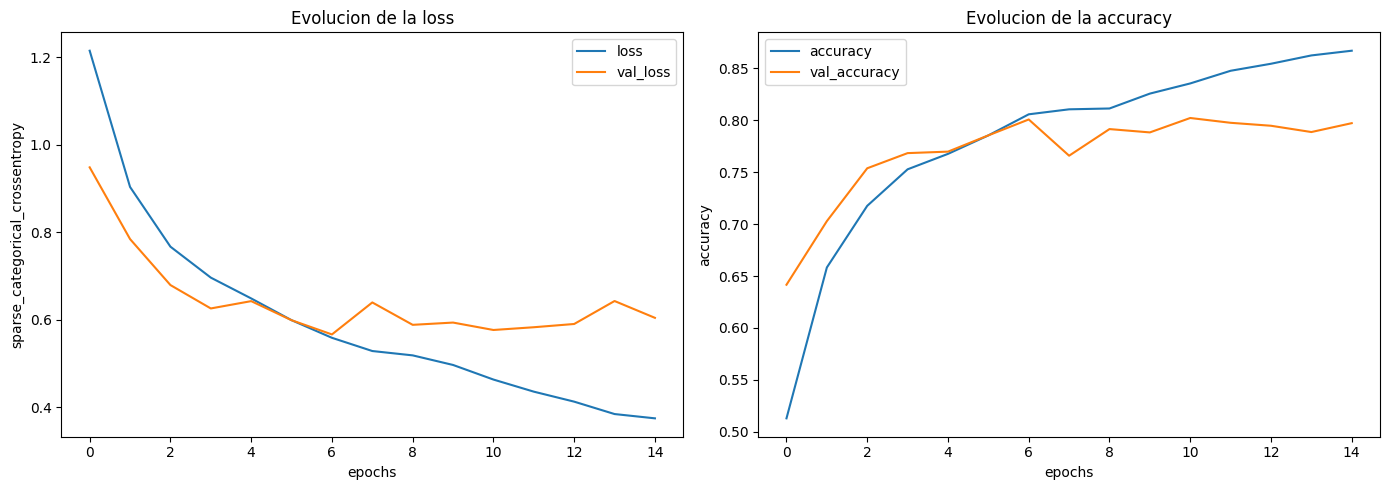

In [23]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

history_df[["loss", "val_loss"]].plot(ax=axes[0])
axes[0].set_title("Evolucion de la loss")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("sparse_categorical_crossentropy")

history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
axes[1].set_title("Evolucion de la accuracy")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("accuracy")

plt.tight_layout()
plt.show()

In [24]:
# Los numeros concretos, para poder comentarlos
mejor_epoca = history_df["val_loss"].idxmin()

print(f"Epocas entrenadas       : {len(history_df)}")
print(f"Mejor epoca (val_loss)  : {mejor_epoca + 1}")
print()
print("En la mejor epoca:")
print(f"   loss     : {history_df.loc[mejor_epoca, 'loss']:.4f}")
print(f"   val_loss : {history_df.loc[mejor_epoca, 'val_loss']:.4f}")
print(f"   accuracy    : {history_df.loc[mejor_epoca, 'accuracy']:.4f}")
print(f"   val_accuracy: {history_df.loc[mejor_epoca, 'val_accuracy']:.4f}")
print(f"   diferencia train-val (accuracy): "
      f"{history_df.loc[mejor_epoca, 'accuracy'] - history_df.loc[mejor_epoca, 'val_accuracy']:+.4f}")
print()
print("En la ultima epoca:")
print(f"   accuracy    : {history_df.iloc[-1]['accuracy']:.4f}")
print(f"   val_accuracy: {history_df.iloc[-1]['val_accuracy']:.4f}")
print(f"   diferencia train-val (accuracy): "
      f"{history_df.iloc[-1]['accuracy'] - history_df.iloc[-1]['val_accuracy']:+.4f}")

Epocas entrenadas       : 15
Mejor epoca (val_loss)  : 7

En la mejor epoca:
   loss     : 0.5586
   val_loss : 0.5663
   accuracy    : 0.8058
   val_accuracy: 0.8009
   diferencia train-val (accuracy): +0.0050

En la ultima epoca:
   accuracy    : 0.8671
   val_accuracy: 0.7973
   diferencia train-val (accuracy): +0.0698


**Comentario de la evolución del entrenamiento**

El `EarlyStopping` ha parado en la **época 15**, y la mejor `val_loss` (0.5663) la
consiguió en la **época 7**. Gracias a `restore_best_weights=True` el modelo que nos
llevamos es el de esa época 7.

Las dos curvas arrancan juntas y bajando rápido: el modelo pasa del 16,7% del azar
a más del 80% de accuracy en validación en apenas 7 épocas.

Lo que hay que mirar es **cómo se separan**:

| | accuracy train | accuracy validación | diferencia |
|---|---|---|---|
| época 7 (la mejor) | 0.806 | 0.801 | +0,5 puntos |
| época 15 (la última) | 0.867 | 0.797 | +7,0 puntos |

En la mejor época las dos van casi pegadas (medio punto de diferencia): el modelo
está generalizando bien. A partir de ahí aparece el **overfitting**: la accuracy de
train sigue subiendo hasta el 87% mientras la de validación se queda plana e incluso
baja un poco, y la `val_loss` empieza a subir.

Aquí se ve el valor de los dos argumentos del callback: `patience=8` le da margen
para intentar salir del estancamiento, y `restore_best_weights=True` es lo que evita
que nos quedemos con el modelo degradado de la época 15.

Que aparezca overfitting es esperable: 14.000 imágenes de 32x32 son pocas para los
619.334 parámetros del modelo.


### Ejercicio 8

Evalua el modelo con los datos de test, además muestra el report de clasificación y la matriz de confusión.



In [25]:
loss_test, accuracy_test = model.evaluate(X_test_esc, y_test_num, verbose=0)

print(f"Loss en test    : {loss_test:.4f}")
print(f"Accuracy en test: {accuracy_test:.4f}  ({accuracy_test:.1%})")
print(f"Baseline (azar) : {1/len(CLASES):.1%}")

Loss en test    : 0.5632
Accuracy en test: 0.7960  (79.6%)
Baseline (azar) : 16.7%


In [26]:
# La red devuelve 6 probabilidades por imagen (una por clase, suman 1 por el softmax).
# La clase predicha es la de mayor probabilidad -> argmax
probabilidades = model.predict(X_test_esc, verbose=0)
y_pred_num = np.argmax(probabilidades, axis=1)

# La confianza es la probabilidad de la clase que ha elegido
confianza = np.max(probabilidades, axis=1)

print("Shape de las probabilidades:", probabilidades.shape)
print()
print("Ejemplo de la primera imagen de test:")
for i, clase in enumerate(CLASES):
    print(f"   {clase:12} {probabilidades[0][i]:.4f}")
print(f"   -> predice '{numero_a_clase[y_pred_num[0]]}' con {confianza[0]:.1%} de confianza")
print(f"   -> la real era '{numero_a_clase[y_test_num[0]]}'")

Shape de las probabilidades: (3000, 6)

Ejemplo de la primera imagen de test:
   buildings    0.9995
   forest       0.0000
   glacier      0.0000
   mountain     0.0000
   sea          0.0001
   street       0.0003
   -> predice 'buildings' con 99.9% de confianza
   -> la real era 'buildings'


In [27]:
print(classification_report(y_test_num, y_pred_num, target_names=CLASES))

              precision    recall  f1-score   support

   buildings       0.72      0.76      0.74       437
      forest       0.95      0.87      0.91       474
     glacier       0.77      0.78      0.77       553
    mountain       0.77      0.77      0.77       525
         sea       0.82      0.73      0.77       510
      street       0.78      0.87      0.82       501

    accuracy                           0.80      3000
   macro avg       0.80      0.80      0.80      3000
weighted avg       0.80      0.80      0.80      3000



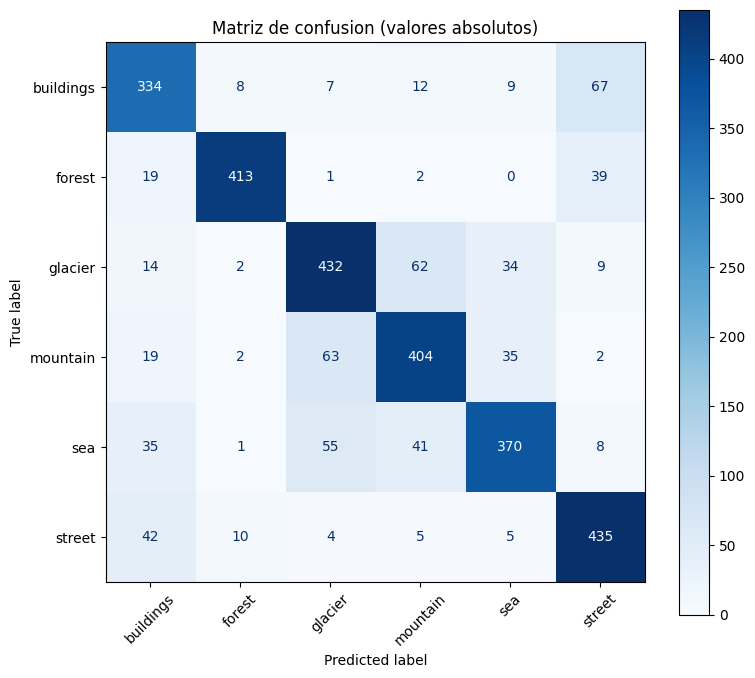

In [28]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test_num, y_pred_num,
    display_labels=CLASES,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
)
ax.set_title("Matriz de confusion (valores absolutos)")
plt.tight_layout()
plt.show()

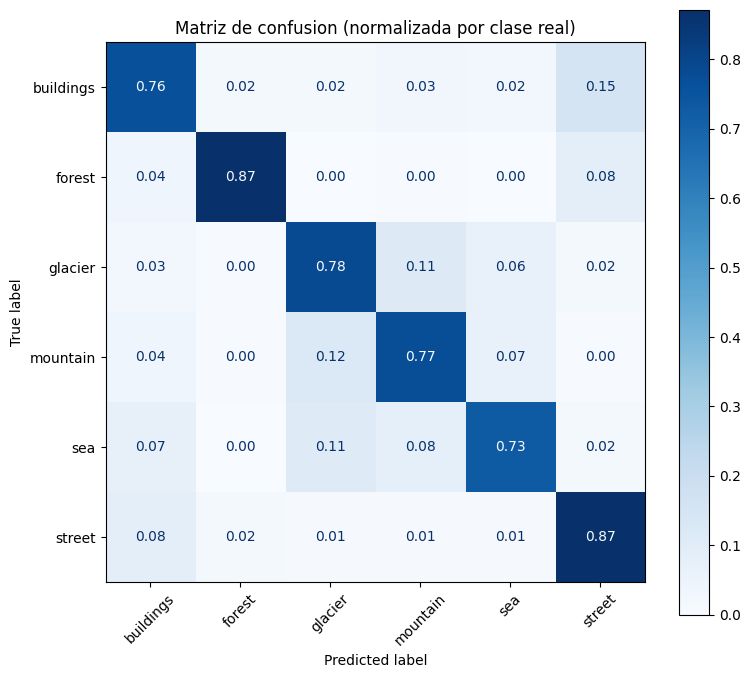

In [29]:
# La misma matriz normalizada por filas: que porcentaje de cada clase real
# va a cada clase predicha. Se lee mucho mejor para comparar clases.
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test_num, y_pred_num,
    display_labels=CLASES,
    cmap="Blues",
    normalize="true",
    values_format=".2f",
    xticks_rotation=45,
    ax=ax,
)
ax.set_title("Matriz de confusion (normalizada por clase real)")
plt.tight_layout()
plt.show()

In [30]:
# Los pares de clases que mas se confunden, en una tabla ordenada
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(y_test_num, y_pred_num)
confusiones = []
for i in range(len(CLASES)):
    for j in range(len(CLASES)):
        if i != j and matriz[i, j] > 0:
            confusiones.append({
                "clase_real": CLASES[i],
                "clase_predicha": CLASES[j],
                "n_imagenes": int(matriz[i, j]),
                "pct_de_la_clase_real": round(100 * matriz[i, j] / matriz[i].sum(), 1),
            })

df_confusiones = pd.DataFrame(confusiones).sort_values(
    "n_imagenes", ascending=False).reset_index(drop=True)
print("Los 8 errores mas frecuentes:")
df_confusiones.head(8)

Los 8 errores mas frecuentes:


,clase_real,clase_predicha,n_imagenes,pct_de_la_clase_real
0,buildings,street,67,15.3
1,mountain,glacier,63,12.0
2,glacier,mountain,62,11.2
3,sea,glacier,55,10.8
4,street,buildings,42,8.4
5,sea,mountain,41,8.0
6,forest,street,39,8.2
7,mountain,sea,35,6.7


**Lectura de los resultados**

Accuracy en test: **79,6%**. Comparado con las dos referencias que tenemos:

| referencia | accuracy |
|---|---|
| azar (6 clases) | 16,7% |
| **baseline RandomForest** | **60,4%** |
| **nuestra CNN** | **79,6%** |

La CNN le saca **19,2 puntos al RandomForest**. Ese es el valor real de aprovechar
la estructura espacial; frente al azar la mejora parecería de 63 puntos, que suena
espectacular pero no dice nada.

El reparto por clases:

| clase | precision | recall | f1 |
|---|---|---|---|
| forest | 0.95 | 0.87 | **0.91** |
| street | 0.78 | 0.87 | 0.82 |
| glacier | 0.77 | 0.78 | 0.78 |
| mountain | 0.77 | 0.77 | 0.77 |
| sea | 0.82 | 0.73 | 0.77 |
| buildings | 0.72 | 0.76 | **0.74** |

* **`forest` es la clase más fácil con diferencia** (f1 = 0.91). Su verde y su
  textura densa son inconfundibles y sobreviven incluso a 32x32. Era la predicción
  del Ejercicio 2 y se cumple.
* **`buildings` es la más difícil** (f1 = 0.74), con la precision más baja de todas
  (0.72): de cada 100 imágenes que el modelo llama "buildings", 28 no lo son.
* Las cuatro del medio se agrupan en una banda muy estrecha, entre 0.74 y 0.82.

Y la tabla de confusiones más frecuentes es la parte más reveladora:

| clase real | predicha como | imágenes | % de su clase |
|---|---|---|---|
| buildings | street | 67 | 15,3% |
| mountain | glacier | 63 | 12,0% |
| glacier | mountain | 62 | 11,2% |
| sea | glacier | 55 | 10,8% |
| street | buildings | 42 | 8,4% |
| sea | mountain | 41 | 8,0% |

Los errores se agrupan en **los dos bloques que predijimos en el Ejercicio 2**:

1. **El bloque urbano**: `buildings` <-> `street` es el error más frecuente de toda
   la matriz (67 + 42 = 109 imágenes). Una foto de calle contiene edificios y una de
   edificios contiene calle: lo que las distingue es cuál es el protagonista de la
   escena, un matiz que esta red no capta. Es lo que hunde a `buildings`.
2. **El bloque de paisaje natural**: `mountain`, `glacier` y `sea` se confunden
   entre sí en todas las direcciones y suman todavía más en total (unas 256
   imágenes). Un glaciar casi siempre tiene montañas alrededor, y a 32x32 la
   diferencia entre roca y hielo se pierde. El horizonte de una montaña nevada y el
   de un mar también se parecen a esta resolución.

La conclusión importante: **los errores del modelo no son aleatorios, son
semánticamente razonables**. Se equivoca en los pares de clases donde una persona
también podría dudar viendo miniaturas de 32x32. Eso es buena señal, significa que
la red ha aprendido características reales de las imágenes y no ruido.


### Ejercicio 9 

Representa algunos de los paisajes donde el modelo comete errores y muestra la confianza que tenía en ellos.





Sacamos las imágenes mal clasificadas y las pintamos con la clase real, la
predicha y la confianza que tenía el modelo.

In [31]:
errores = np.where(y_pred_num != y_test_num)[0]

print(f"Imagenes mal clasificadas: {len(errores)} de {len(y_test_num)} "
      f"({len(errores)/len(y_test_num):.1%})")
print(f"Confianza media en los errores : {confianza[errores].mean():.1%}")
print(f"Confianza media en los aciertos: {confianza[y_pred_num == y_test_num].mean():.1%}")

Imagenes mal clasificadas: 612 de 3000 (20.4%)
Confianza media en los errores : 61.0%
Confianza media en los aciertos: 82.2%


Un primer dato interesante: **el modelo está menos seguro cuando se equivoca**. La
confianza media en los aciertos es bastante más alta que en los errores, lo cual es
buena señal (la confianza del softmax es informativa, no está dando probabilidades
al azar).

Vemos una muestra aleatoria de errores:

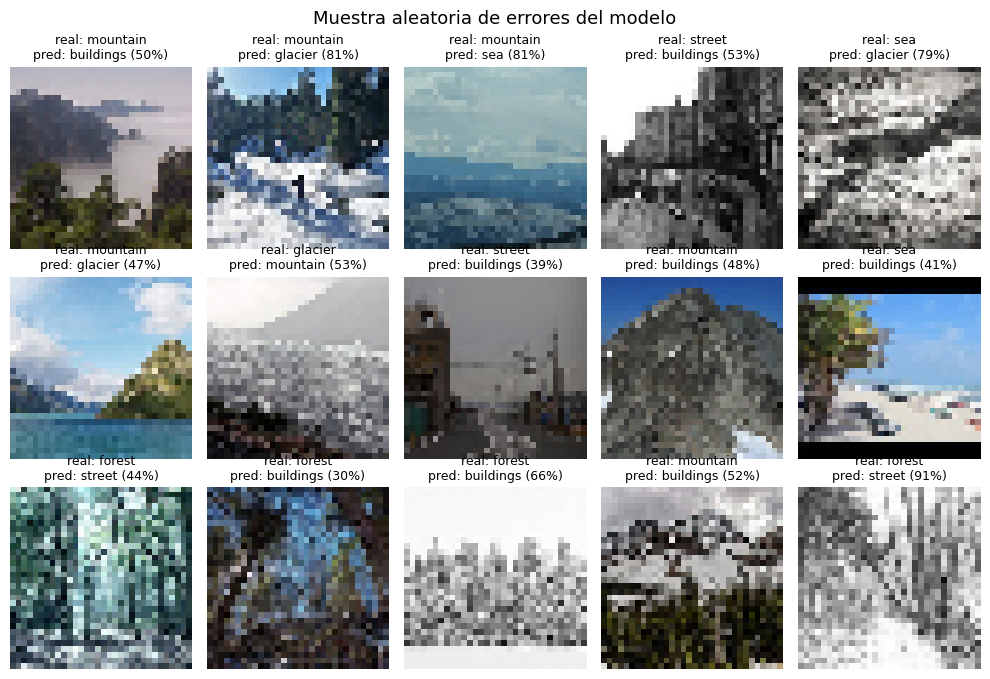

In [32]:
muestra_errores = np.random.choice(errores, 15, replace=False)

etiquetas = [
    f"real: {numero_a_clase[y_test_num[i]]}\n"
    f"pred: {numero_a_clase[y_pred_num[i]]} ({confianza[i]:.0%})"
    for i in muestra_errores
]

plot_imagenes(X_test[muestra_errores], etiquetas, n_cols=5,
              titulo="Muestra aleatoria de errores del modelo")

Y ahora los errores **más graves**: aquellos en los que el modelo se equivoca
estando muy seguro de sí mismo. Son los más informativos, porque muestran dónde el
modelo tiene un sesgo real y no una simple duda.

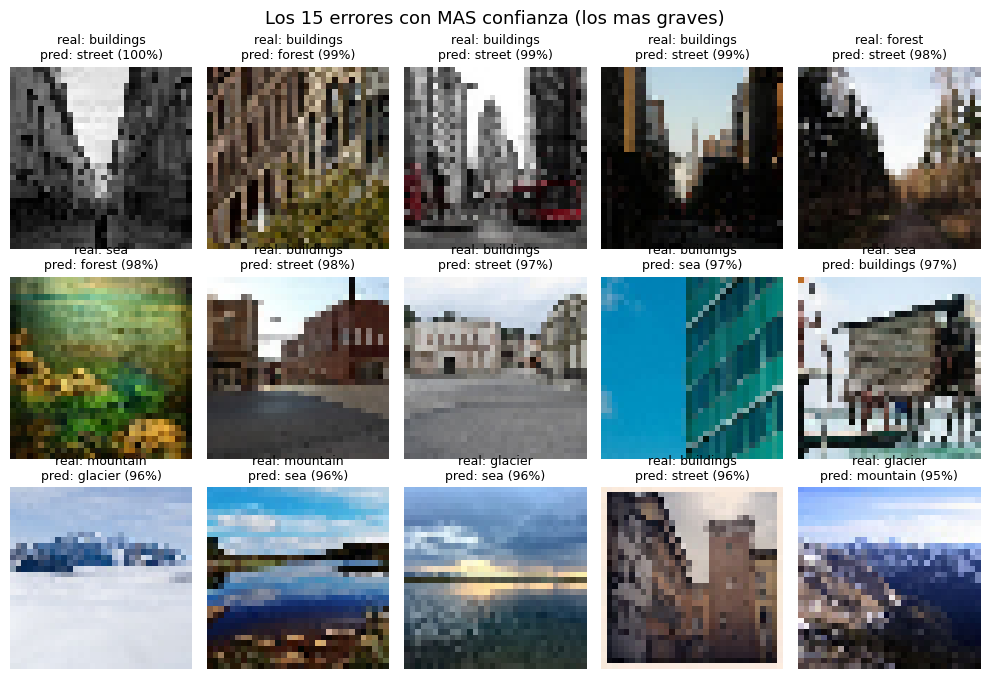

In [33]:
# Ordenamos los errores por confianza descendente y cogemos los 15 peores
peores = errores[np.argsort(-confianza[errores])][:15]

etiquetas = [
    f"real: {numero_a_clase[y_test_num[i]]}\n"
    f"pred: {numero_a_clase[y_pred_num[i]]} ({confianza[i]:.0%})"
    for i in peores
]

plot_imagenes(X_test[peores], etiquetas, n_cols=5,
              titulo="Los 15 errores con MAS confianza (los mas graves)")

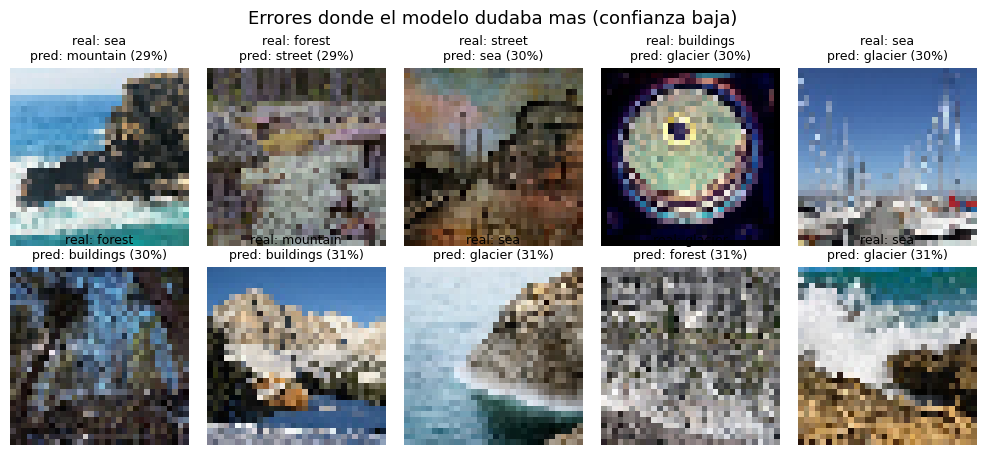

In [34]:
# Y el caso contrario: los errores donde el modelo dudaba mas.
# Aqui el fallo es "comprensible", estaba entre dos opciones.
menos_seguros = errores[np.argsort(confianza[errores])][:10]

etiquetas = [
    f"real: {numero_a_clase[y_test_num[i]]}\n"
    f"pred: {numero_a_clase[y_pred_num[i]]} ({confianza[i]:.0%})"
    for i in menos_seguros
]

plot_imagenes(X_test[menos_seguros], etiquetas, n_cols=5,
              titulo="Errores donde el modelo dudaba mas (confianza baja)")

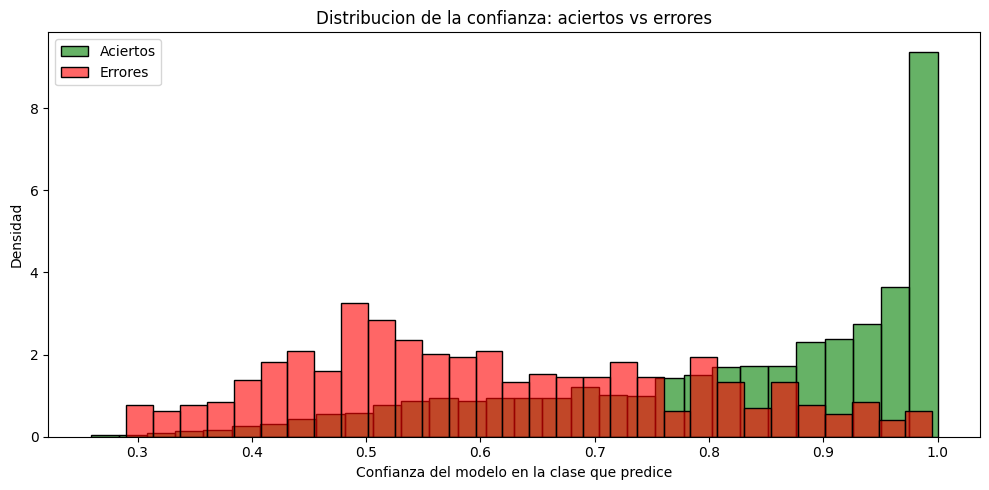

In [35]:
# Vemos tambien la distribucion de la confianza: aciertos vs errores
plt.figure(figsize=(10, 5))
sns.histplot(confianza[y_pred_num == y_test_num], bins=30, label="Aciertos",
             color="green", alpha=0.6, stat="density")
sns.histplot(confianza[errores], bins=30, label="Errores",
             color="red", alpha=0.6, stat="density")
plt.xlabel("Confianza del modelo en la clase que predice")
plt.ylabel("Densidad")
plt.title("Distribucion de la confianza: aciertos vs errores")
plt.legend()
plt.tight_layout()
plt.show()

**Conclusiones del análisis de errores**

1. **La confianza del modelo es informativa.** La confianza media es del **82,2% en
   los aciertos** y del **61,0% en los errores**, y el histograma lo confirma: los
   aciertos se acumulan pegados al 100% mientras los errores están muy repartidos
   hacia valores bajos. Esto es útil en la práctica: se podría fijar un umbral de
   confianza y derivar a revisión manual todo lo que baje de él, en lugar de aceptar
   todas las predicciones por igual.

2. **612 imágenes mal clasificadas de 3000 (20,4%).** Según la tabla del Ejercicio
   8, la mayoría se concentran en solo dos bloques de clases: el urbano
   (`buildings`/`street`) y el natural (`mountain`/`glacier`/`sea`).

3. **Los errores con confianza alta son los preocupantes.** Son casos donde el
   modelo no duda pero se equivoca, es decir donde tiene un sesgo real y no una
   simple indecisión. Mirando las imágenes se ve que muchos son escenas
   genuinamente ambiguas: montañas nevadas en las que decidir si el protagonista es
   el glaciar o la montaña es discutible incluso para una persona.

4. **Los errores con confianza baja son los "razonables".** Imágenes con niebla, muy
   oscuras, o donde caben dos categorías a la vez (una calle arbolada que podría ser
   `street` y `forest`). Aquí el modelo estaba entre dos opciones y eligió mal, que
   es un fallo mucho más benigno.

5. Buena parte de estos fallos parece venir de **la resolución**: a 32x32 se pierde
   toda la textura fina que distingue el hielo de la roca o el asfalto del tejado.
   Es exactamente la hipótesis que vamos a poner a prueba en el ejercicio EXTRA.

### Ejercicio EXTRA: 

Aumenta la resolución y repite el ejercicio con la misma topología de red

El enunciado pide **subir la resolución y repetir con la misma topología de red**.
Pasamos de 32x32 a **64x64**, que es cuatro veces más píxeles por imagen.

La hipótesis que queremos comprobar es la del Ejercicio 9: si los errores vienen de
que a 32x32 se pierde la textura fina, al subir la resolución deberían mejorar
sobre todo `glacier` y `mountain`.

Antes de cargar, un detalle práctico: los arrays de 64x64 ocupan 4 veces más
memoria que los de 32x32. Para no quedarnos sin RAM, **liberamos primero los
arrays escalados de 32x32** que ya no necesitamos (conservamos `X_test` sin
escalar, que hace falta para pintar imágenes, y los resultados que queremos
comparar).

In [36]:
# Guardamos los resultados de 32x32 que queremos comparar despues
resultados_32 = {
    "resolucion": "32x32",
    "parametros": model.count_params(),
    "epocas": len(history_df),
    "mejor_val_loss": round(history_df["val_loss"].min(), 4),
    "loss_test": round(loss_test, 4),
    "accuracy_test": round(accuracy_test, 4),
    "errores": int(len(errores)),
}
print(resultados_32)

# Liberamos memoria: los arrays escalados de 32x32 ya no hacen falta
del X_train_esc, X_test_esc, X_train
gc.collect()
print("\nMemoria liberada.")

{'resolucion': '32x32', 'parametros': 619334, 'epocas': 15, 'mejor_val_loss': np.float64(0.5663), 'loss_test': 0.5632, 'accuracy_test': 0.796, 'errores': 612}



Memoria liberada.


In [37]:
# Volvemos a cargar, ahora a 64x64. Tarda otros ~50 segundos.
RESHAPE_DIM_64 = (64, 64)

X_train_64, y_train_64 = read_data(TRAIN_PATH, RESHAPE_DIM_64)
X_test_64, y_test_64 = read_data(TEST_PATH, RESHAPE_DIM_64)

print("TRAIN -> X:", X_train_64.shape)
print("TEST  -> X:", X_test_64.shape)
print(f"Memoria X_train_64: {X_train_64.nbytes / 1e6:.1f} MB "
      f"(4 veces mas que a 32x32)")

TRAIN -> X: (14034, 64, 64, 3)
TEST  -> X: (3000, 64, 64, 3)
Memoria X_train_64: 172.4 MB (4 veces mas que a 32x32)


Se ve la diferencia de detalle al comparar la misma escena a las dos resoluciones.
Comparamos unas cuantas imágenes de `glacier` y `mountain`, que son las clases que
peor se le daban al modelo:

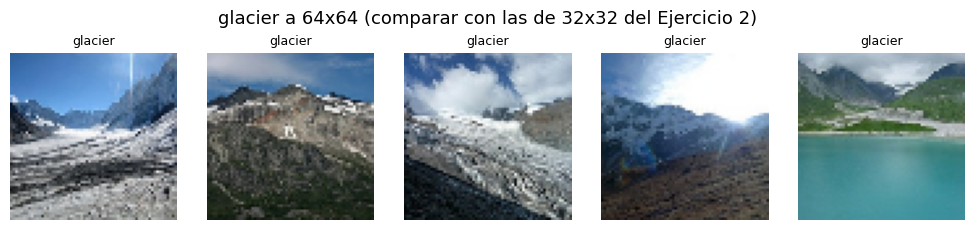

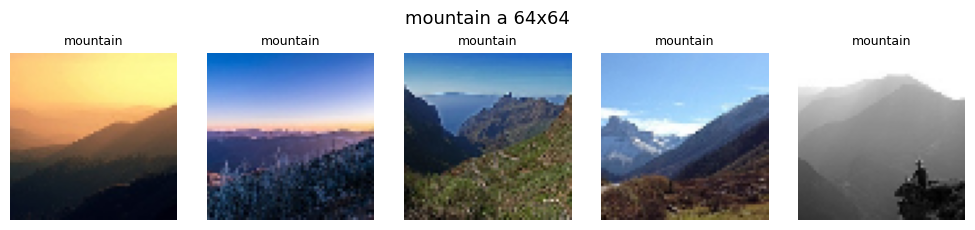

In [38]:
# Las mismas 5 imagenes de glacier a 64x64: se aprecia mucho mas detalle
indices_glacier = np.where(y_train_64 == "glacier")[0][:5]
plot_imagenes(X_train_64[indices_glacier], ["glacier"] * 5, n_cols=5,
              titulo="glacier a 64x64 (comparar con las de 32x32 del Ejercicio 2)")

indices_mountain = np.where(y_train_64 == "mountain")[0][:5]
plot_imagenes(X_train_64[indices_mountain], ["mountain"] * 5, n_cols=5,
              titulo="mountain a 64x64")

In [39]:
# Preparamos igual que antes: escalar, etiquetas a numero y BARAJAR
X_train_64_esc = (X_train_64 / 255.0).astype("float32")
X_test_64_esc = (X_test_64 / 255.0).astype("float32")

y_train_64_num = np.array([clase_a_numero[c] for c in y_train_64])
y_test_64_num = np.array([clase_a_numero[c] for c in y_test_64])

X_train_64_esc, y_train_64_num = shuffle(
    X_train_64_esc, y_train_64_num, random_state=SEMILLA
)

print("Preparado. X_train_64_esc:", X_train_64_esc.shape, X_train_64_esc.dtype)
print(f"Memoria: {X_train_64_esc.nbytes / 1e6:.1f} MB")

Preparado. X_train_64_esc: (14034, 64, 64, 3) float32
Memoria: 689.8 MB


Y ahora **la misma topología**, cambiando solo el `input_shape`. Es interesante
fijarse en lo que le pasa al número de parámetros.

In [40]:
model_64 = Sequential([
    # Lo unico que cambia: 64x64 en lugar de 32x32
    Input(shape=(64, 64, 3)),

    Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),          # 64x64 -> 32x32

    Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),          # 32x32 -> 16x16
    Dropout(0.25),

    Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),          # 16x16 -> 8x8
    Dropout(0.25),

    Flatten(),                               # 8x8x128 -> 8192 features
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(len(CLASES), activation="softmax"),
])

model_64.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model_64.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,192,198 (8.36 MB)

 Trainable params: 2,192,198 (8.36 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
print(f"Parametros a 32x32: {resultados_32['parametros']:,}")
print(f"Parametros a 64x64: {model_64.count_params():,}")
print(f"Han crecido x{model_64.count_params() / resultados_32['parametros']:.1f}")

Parametros a 32x32: 619,334
Parametros a 64x64: 2,192,198
Han crecido x3.5


**Un detalle importante de la teoría que se ve aquí perfectamente.** Hemos usado
*exactamente* la misma topología, pero los parámetros pasan de 619.334 a 2.192.198,
más del triple. ¿Por qué, si las capas son las mismas?

Porque **las capas convolucionales no cambian nada** (un `Conv2D(64, 3x3)` tiene
los mismos pesos sea la imagen de 32x32 o de 1000x1000: comparte el filtro por
toda la imagen). Lo que cambia es **la salida del `Flatten`**:

* a 32x32 -> los tres poolings dejan 4x4x128 = **2.048** features -> Dense(256) = 524.544 pesos
* a 64x64 -> los tres poolings dejan 8x8x128 = **8.192** features -> Dense(256) = 2.097.408 pesos

Es decir, todo el crecimiento se lo come la primera capa densa. Es el argumento de
la teoría llevado al extremo: si quisiéramos subir a 224x224 la capa densa se haría
inmanejable. La solución que usan las arquitecturas modernas es poner un
`GlobalAveragePooling2D` en lugar del `Flatten`, pero eso ya no es "la misma
topología" que pide el enunciado.

Entrenamos. Ojo: a esta resolución cada época tarda unos 20 segundos en lugar de 5,
así que esto va a llevar varios minutos.

In [42]:
early_stopping_64 = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1,
)

history_64 = model_64.fit(
    X_train_64_esc, y_train_64_num,
    batch_size=64,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stopping_64],
    verbose=2,
)

Epoch 1/50


176/176 - 21s - 120ms/step - accuracy: 0.5238 - loss: 1.1886 - val_accuracy: 0.6455 - val_loss: 0.9162


Epoch 2/50


176/176 - 17s - 97ms/step - accuracy: 0.6639 - loss: 0.8854 - val_accuracy: 0.7189 - val_loss: 0.7648


Epoch 3/50


...

176/176 - 17s - 96ms/step - accuracy: 0.8926 - loss: 0.2892 - val_accuracy: 0.8269 - val_loss: 0.5831


Epoch 16/50


176/176 - 17s - 96ms/step - accuracy: 0.9029 - loss: 0.2762 - val_accuracy: 0.8269 - val_loss: 0.5674


Epoch 16: early stopping


Restoring model weights from the end of the best epoch: 8.


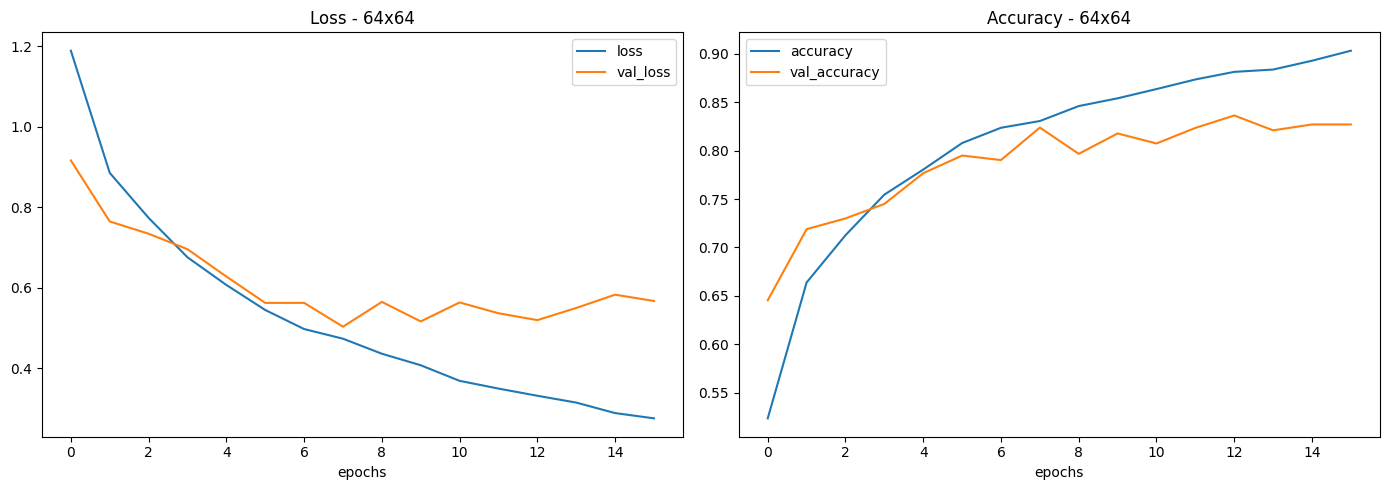

Epocas: 16 | mejor val_loss: 0.5036 (epoca 8)


In [43]:
history_64_df = pd.DataFrame(history_64.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

history_64_df[["loss", "val_loss"]].plot(ax=axes[0])
axes[0].set_title("Loss - 64x64")
axes[0].set_xlabel("epochs")

history_64_df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
axes[1].set_title("Accuracy - 64x64")
axes[1].set_xlabel("epochs")

plt.tight_layout()
plt.show()

print(f"Epocas: {len(history_64_df)} | mejor val_loss: "
      f"{history_64_df['val_loss'].min():.4f} "
      f"(epoca {history_64_df['val_loss'].idxmin() + 1})")

In [44]:
loss_test_64, accuracy_test_64 = model_64.evaluate(X_test_64_esc, y_test_64_num, verbose=0)

print(f"Loss en test    : {loss_test_64:.4f}")
print(f"Accuracy en test: {accuracy_test_64:.4f}  ({accuracy_test_64:.1%})")
print()

probabilidades_64 = model_64.predict(X_test_64_esc, verbose=0)
y_pred_64 = np.argmax(probabilidades_64, axis=1)
confianza_64 = np.max(probabilidades_64, axis=1)

print(classification_report(y_test_64_num, y_pred_64, target_names=CLASES))

Loss en test    : 0.5001
Accuracy en test: 0.8243  (82.4%)



              precision    recall  f1-score   support

   buildings       0.81      0.78      0.79       437
      forest       0.91      0.96      0.94       474
     glacier       0.83      0.74      0.78       553
    mountain       0.72      0.85      0.78       525
         sea       0.88      0.75      0.81       510
      street       0.82      0.87      0.84       501

    accuracy                           0.82      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.82      0.82      3000



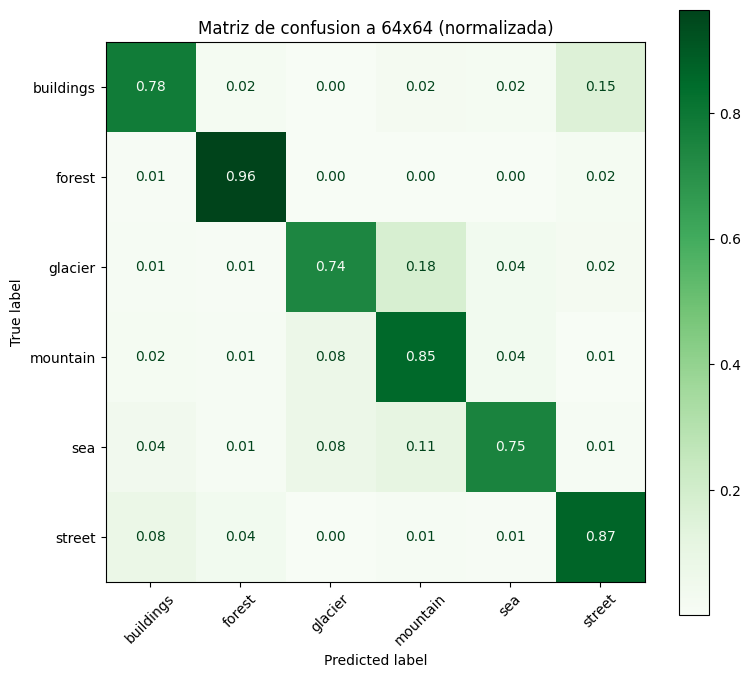

In [45]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test_64_num, y_pred_64,
    display_labels=CLASES,
    cmap="Greens",
    normalize="true",
    values_format=".2f",
    xticks_rotation=45,
    ax=ax,
)
ax.set_title("Matriz de confusion a 64x64 (normalizada)")
plt.tight_layout()
plt.show()

### Comparativa de las dos resoluciones

In [46]:
errores_64 = np.where(y_pred_64 != y_test_64_num)[0]

resultados_64 = {
    "resolucion": "64x64",
    "parametros": model_64.count_params(),
    "epocas": len(history_64_df),
    "mejor_val_loss": round(history_64_df["val_loss"].min(), 4),
    "loss_test": round(loss_test_64, 4),
    "accuracy_test": round(accuracy_test_64, 4),
    "errores": int(len(errores_64)),
}

comparativa = pd.DataFrame([resultados_32, resultados_64])
comparativa

,resolucion,parametros,epocas,mejor_val_loss,loss_test,accuracy_test,errores
0,32x32,619334,15,0.5663,0.5632,0.7960,612
1,64x64,2192198,16,0.5036,0.5001,0.8243,527


In [47]:
# Comparamos el f1-score por clase en las dos resoluciones
from sklearn.metrics import f1_score

f1_32 = f1_score(y_test_num, y_pred_num, average=None)
f1_64 = f1_score(y_test_64_num, y_pred_64, average=None)

df_f1 = pd.DataFrame({
    "clase": CLASES,
    "f1_32x32": np.round(f1_32, 3),
    "f1_64x64": np.round(f1_64, 3),
})
df_f1["diferencia"] = np.round(df_f1["f1_64x64"] - df_f1["f1_32x32"], 3)
df_f1 = df_f1.sort_values("diferencia", ascending=False).reset_index(drop=True)
df_f1

,clase,f1_32x32,f1_64x64,diferencia
0,buildings,0.742,0.794,0.052
1,sea,0.768,0.810,0.042
2,forest,0.908,0.938,0.030
3,street,0.820,0.842,0.022
4,mountain,0.769,0.783,0.014
5,glacier,0.775,0.784,0.009


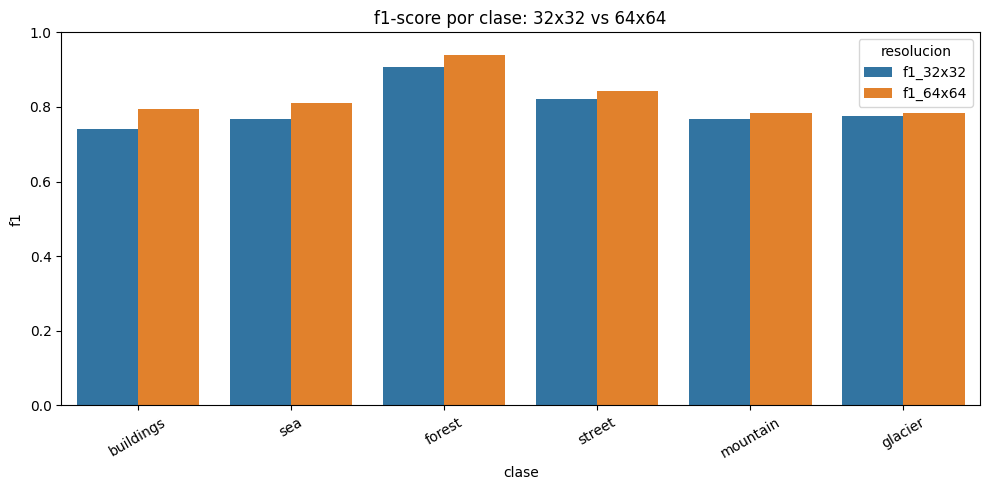

In [48]:
# Lo mismo pero en grafico, que se ve mejor
df_plot = df_f1.melt(id_vars="clase", value_vars=["f1_32x32", "f1_64x64"],
                     var_name="resolucion", value_name="f1")

plt.figure(figsize=(10, 5))
sns.barplot(data=df_plot, x="clase", y="f1", hue="resolucion")
plt.title("f1-score por clase: 32x32 vs 64x64")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Lectura de la comparativa: la hipótesis se cumple, pero no como esperábamos**

Subir a 64x64 **sí mejora el modelo**, y en todos los frentes:

| | 32x32 | 64x64 |
|---|---|---|
| accuracy test | 79,6% | **82,4%** |
| loss test | 0.5632 | **0.5001** |
| mejor val_loss | 0.5663 | **0.5036** |
| errores | 612 | **527** |

Son **2,8 puntos de accuracy** y **85 errores menos**. Y lo más sólido: **las seis
clases mejoran**, ninguna empeora.

Pero aquí está el matiz que no esperaba. Nuestra hipótesis del Ejercicio 9 era que
la resolución extra ayudaría sobre todo a `glacier` y `mountain`, porque a 32x32 no
se distingue el hielo de la roca. Mirando la tabla de f1 por clase, ha pasado justo
lo contrario:

| clase | ganancia de f1 |
|---|---|
| buildings | **+0,052** |
| sea | +0,042 |
| forest | +0,030 |
| street | +0,022 |
| mountain | +0,014 |
| glacier | **+0,009** |

Las que más ganan son `buildings` y `sea`; **`glacier` y `mountain` son las que
menos ganan de las seis**. Es decir: los píxeles extra sirven para separar edificios
de calles y mar de montaña, pero **apenas ayudan a separar el hielo de la roca**.

Eso nos dice algo útil sobre el problema: la confusión `glacier` <-> `mountain` **no
es un problema de resolución**, es una ambigüedad semántica real. Muchas fotos de
glaciar *son* fotos de montaña con hielo, y ninguna cantidad de píxeles va a
resolver una etiqueta que es discutible de partida. Para atacar ese par harían falta
más datos o un modelo mucho más potente, no más resolución.

El precio de la mejora: **4 veces más memoria** y unas **4 veces más tiempo por
época** (de ~5s a ~20s), más 3,5 veces más parámetros.

***
## Conclusiones finales del ejercicio

**Sobre el modelo (32x32)**

1. Una CNN de tres bloques Conv-Pool entrenada desde cero clasifica 6 tipos de
   paisaje con un **79,6% de accuracy**.
2. Lo importante es contra qué se compara. El **baseline con RandomForest sobre
   píxeles planos da 60,4%**, así que la CNN aporta **19,2 puntos** por aprovechar la
   estructura espacial. Frente al azar (16,7%) la mejora parecería de 63 puntos, pero
   eso sería engañarnos.
3. El baseline dio además una pista valiosa: **en RGB saca 60,4% y en escala de
   grises solo 52,5%**. Casi 8 puntos de diferencia, o sea que aquí **el color es
   información de verdad** (el verde de `forest`, el azul de `sea`). Al contrario de
   lo que pasaría en un problema de perros y gatos.
4. El **overfitting** aparece pronto: en la mejor época (la 7) train y validación van
   a medio punto, y en la última (la 15) ya se han separado 7 puntos. El
   `EarlyStopping` con `restore_best_weights=True` es lo que impide que nos llevemos
   el modelo degradado.
5. Los errores **no son aleatorios**: se concentran en el bloque urbano
   (`buildings`/`street`, 109 imágenes) y el natural (`mountain`/`glacier`/`sea`,
   unas 256). Son pares semánticamente parecidos, así que la red ha aprendido
   características reales. `forest` es la clase más fácil (f1 = 0.91) y `buildings`
   la más difícil (f1 = 0.74).
6. La **confianza del softmax es informativa** (82,2% en aciertos frente a 61,0% en
   errores), lo que permitiría usar un umbral para derivar los casos dudosos a
   revisión manual.

**Sobre la resolución (ejercicio EXTRA)**

7. Subir a 64x64 **mejora de forma clara**: 82,4% frente a 79,6% de accuracy, 527
   errores frente a 612, mejor loss en validación y en test, y **las seis clases
   mejoran** sin excepción.
8. Pero la hipótesis concreta que teníamos **era equivocada**. Esperábamos que
   ganaran sobre todo `glacier` y `mountain` (las que peor iban por la textura), y
   son precisamente **las dos que menos ganan** (+0,009 y +0,014 de f1). Las que más
   se benefician son `buildings` (+0,052) y `sea` (+0,042).
9. La lectura de eso: la confusión `glacier` <-> `mountain` **no es un problema de
   resolución sino de ambigüedad de las propias etiquetas**. Un glaciar fotografiado
   de lejos es una montaña con hielo, y más píxeles no arreglan una etiqueta
   discutible. Para ese par haría falta más datos o un modelo más potente.
10. El precio: 4 veces más memoria, ~4 veces más tiempo por época, y con **la misma
    topología** los parámetros pasan de 619.334 a 2.192.198 (x3,5). Todo el
    crecimiento está en la primera capa densa, porque las convolucionales no dependen
    del tamaño de la imagen. Es la teoría de la unidad convertida en número.
11. Un detalle del callback que conviene tener en cuenta: en el modelo de 64x64 la
    mejor `val_loss` cae en la época 8 (val_accuracy 0.824) pero la `val_accuracy`
    sigue subiendo hasta **0.836 en la época 13**. Como el `EarlyStopping` vigila
    `val_loss`, nos quedamos con unos pesos que tienen 1,2 puntos menos de accuracy
    de los que podríamos haber tenido. En el modelo de 32x32 este desacople es
    mínimo (0,1 puntos), así que es un efecto del modelo grande. Merece la pena
    plantearse monitorizar la métrica que de verdad importa.

**Siguientes pasos**

12. Por orden de rentabilidad esperada:
    * **Transfer learning** (Unidad 2): partir de una red ya entrenada con millones
      de imágenes en lugar de aprender los bordes desde cero. Con diferencia, lo que
      más va a mejorar.
    * **Subir más la resolución**, ya que a 64x64 la mejora es clara y no se ve
      agotada. El límite lo pone el tiempo de cómputo.
    * **Aumentado de imágenes** para atacar el overfitting, con transformaciones que
      tengan sentido aquí (un volteo horizontal sí; uno vertical daría paisajes del
      revés).
    * Sustituir el `Flatten` por un `GlobalAveragePooling2D`, que permitiría subir la
      resolución sin que la capa densa se dispare.